Подключение гугл драйв и установка библиотек


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install segyio numpy matplotlib scipy

import os
import segyio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

if os.path.exists(file_path):
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Файл найден. Размер: {size:.2f} МБ")
else:
    print("Файл не найден. Проверь путь.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 2.3 MB/s eta 0:00:00
Файл найден. Размер: 1876.19 МБ


Загрузка последних 700 трасс из SEG-Y файла


In [4]:
with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size

    n_traces = min(700, n_traces_total)
    start_trace = n_traces_total - n_traces

    seismic_data = np.zeros((n_samples, n_traces))

    for i in range(n_traces):
        trace_idx = start_trace + i
        seismic_data[:, i] = segyfile.trace[trace_idx][:n_samples]

    seismic_data_norm = seismic_data / np.max(np.abs(seismic_data))

Вычисление локального наклона волнового поля

In [3]:
def compute_local_dip(data, smooth_sigma=3):
    grad_x = ndimage.sobel(data, axis=1)
    grad_z = ndimage.sobel(data, axis=0)

    grad_x_smooth = ndimage.gaussian_filter(grad_x, sigma=smooth_sigma)
    grad_z_smooth = ndimage.gaussian_filter(grad_z, sigma=smooth_sigma)

    gxx = ndimage.gaussian_filter(grad_x_smooth ** 2, sigma=smooth_sigma)
    gzz = ndimage.gaussian_filter(grad_z_smooth ** 2, sigma=smooth_sigma)
    gxz = ndimage.gaussian_filter(grad_x_smooth * grad_z_smooth, sigma=smooth_sigma)

    denominator = gxx - gzz
    denominator = np.where(np.abs(denominator) < 1e-10, 1e-10, denominator)

    dip_rad = 0.5 * np.arctan2(2 * gxz, denominator)
    dip_deg = np.degrees(dip_rad)

    return dip_deg

dip_deg = compute_local_dip(seismic_data_norm, smooth_sigma=5)

Построение селективного изображения для угла –30°

In [5]:
target_dip = -30
sigma_angle = 12

weights = np.exp(-((dip_deg - target_dip) ** 2) / (2 * sigma_angle ** 2))
selective_image = seismic_data_norm * weights

Визуализация результатов: исходный разрез, карта наклонов, селективное изображение

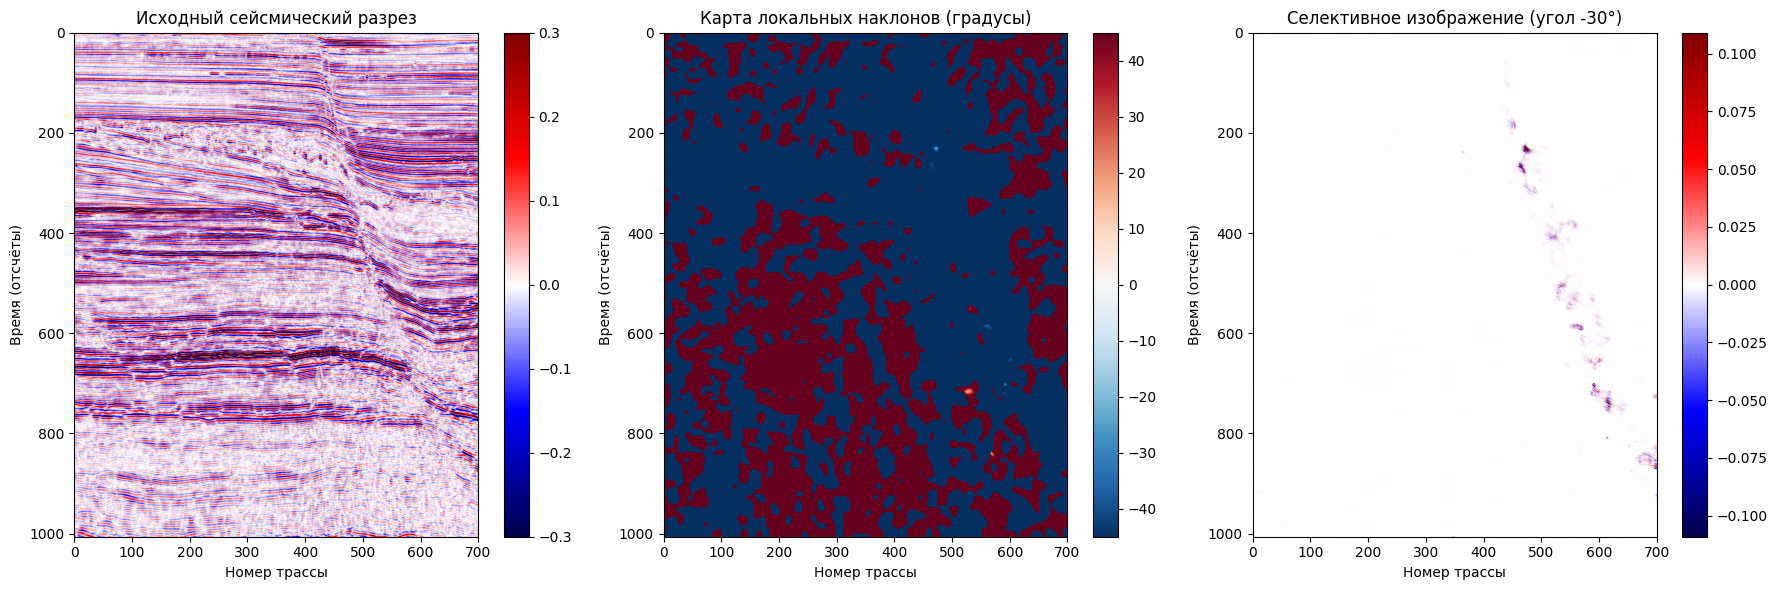

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vmax_orig = 0.3 * np.max(np.abs(seismic_data_norm))
im1 = axes[0].imshow(seismic_data_norm, aspect='auto', cmap='seismic',
                     vmin=-vmax_orig, vmax=vmax_orig,
                     extent=[0, seismic_data.shape[1], seismic_data.shape[0], 0])
axes[0].set_title('Исходный сейсмический разрез', fontsize=12)
axes[0].set_xlabel('Номер трассы')
axes[0].set_ylabel('Время (отсчёты)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(dip_deg, aspect='auto', cmap='RdBu_r',
                     vmin=-45, vmax=45,
                     extent=[0, seismic_data.shape[1], seismic_data.shape[0], 0])
axes[1].set_title('Карта локальных наклонов (градусы)', fontsize=12)
axes[1].set_xlabel('Номер трассы')
axes[1].set_ylabel('Время (отсчёты)')
plt.colorbar(im2, ax=axes[1])

vmax_sel = 0.5 * np.max(np.abs(selective_image))
im3 = axes[2].imshow(selective_image, aspect='auto', cmap='seismic',
                     vmin=-vmax_sel, vmax=vmax_sel,
                     extent=[0, seismic_data.shape[1], seismic_data.shape[0], 0])
axes[2].set_title(f'Селективное изображение (угол {target_dip}°)', fontsize=12)
axes[2].set_xlabel('Номер трассы')
axes[2].set_ylabel('Время (отсчёты)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

Наложение селективного изображения на исходный разрез

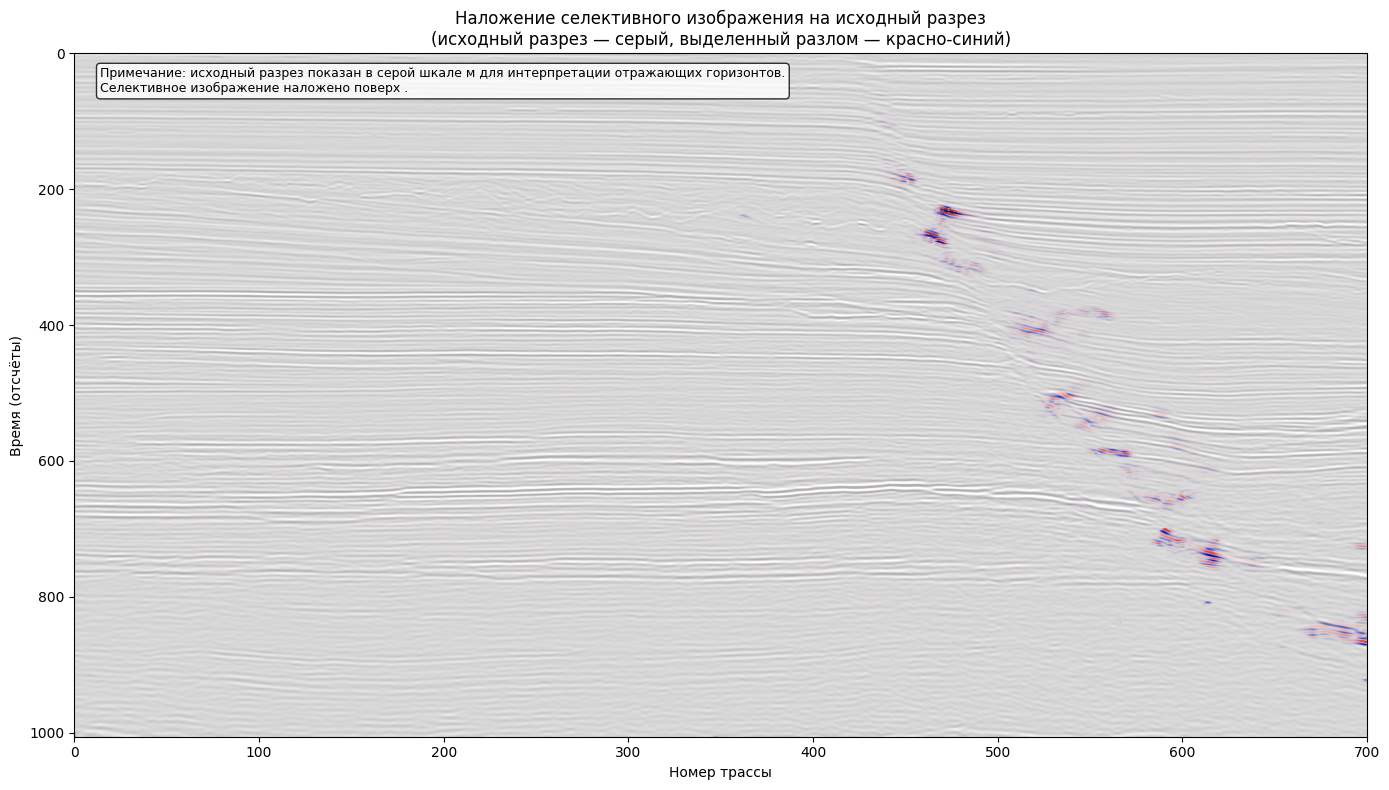

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))

vmax_orig = 0.3 * np.max(np.abs(seismic_data_norm))
ax.imshow(seismic_data_norm, aspect='auto', cmap='gray',
          vmin=-vmax_orig, vmax=vmax_orig,
          extent=[0, seismic_data.shape[1], seismic_data.shape[0], 0])

ax.imshow(selective_image, aspect='auto', cmap='seismic', alpha=0.7,
          vmin=-vmax_sel, vmax=vmax_sel,
          extent=[0, seismic_data.shape[1], seismic_data.shape[0], 0])

ax.set_title('Наложение селективного изображения на исходный разрез\n(исходный разрез — серый, выделенный разлом — красно-синий)', fontsize=12)
ax.set_xlabel('Номер трассы')
ax.set_ylabel('Время (отсчёты)')

# Добавляем пояснение на самом рисунке
ax.text(0.02, 0.98, 'Примечание: исходный разрез показан в серой шкале м для интерпретации отражающих горизонтов.\nСелективное изображение наложено поверх .',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()